# Notebook 1: Data Organisation and Augmentation for CT Segmentation

## Introduction

In this notebook, we will introduce the data preparation steps used for training a U-Net segmentation model on X-ray CT data.

The wider workflow for this workshop is based on a pretrained model that was trained using simulated CT data. The simulated data were generated using a gVXR-based CT simulation script. This script creates paired datasets consisting of reconstructed CT image slices and their corresponding label images. Each simulated case is generated using a controlled set of scan parameters, including sample ID, accelerating voltage, source-object distance, exposure time, and beam current.

This is useful because simulated data can provide automatically generated labels, avoiding the need to manually segment every training image. However, the final goal is not simply to perform well on simulated data. The aim is to train a model that can be applied to real experimental CT data.

This notebook focuses on two practical ideas:

1. How to organise paired CT images and segmentation masks.
2. How to apply data augmentation safely, without breaking the relationship between each image and its mask.

The notebook is intended as a guided walkthrough rather than a live training exercise. The key aim is to understand the structure of the training data and the principles behind augmentation before moving on to model training and inference.

## Directory structure

This notebook assumes the workshop folder is organised as follows:

```text
gVXR-training-dXCT2026/
├── data/
│   ├── morning/
│   └── afternoon/
│       ├── simulated_data/
│       │   ├── CT_data/ # Generated as in simulated_data_generation.py
│       │   └── Labels/ # Generated as in simulated_data_generation.py
│       ├── real_data/
│       │   ├── CT_data/
│       │   └── Labels/
│       └── models/
├── notebooks/
│   ├── morning/
│   └── afternoon/
│       ├── 01_data_organisation_and_augmentation.ipynb
│       ├── 02_unet_training_walkthrough.ipynb
│       └── 03_live_inference_pretrained_unet.ipynb
├── environment.yml
├── README.md
└── LICENSE
```
## Dataset context

The simulated dataset contains paired image and mask files:

```text
CT_data/
    CT-<sample_id>-<voltage_kV>-<SOD_mm>-<exposure_s>-<current_uA>_idx_0000.tiff

Labels/
    labels-<sample_id>-<voltage_kV>-<SOD_mm>-<exposure_s>-<current_uA>.tiff
```

The shared part of each filename acts as a unique key linking a CT image to its corresponding label image:

```text
<sample_id>-<voltage_kV>-<SOD_mm>-<exposure_s>-<current_uA>
```

This key should be used to match image-mask pairs. This is more reliable than simply sorting two folders and assuming that the files are in the same order.

## Why augmentation matters

A segmentation model should be able to recognise the target structure despite small changes in position, orientation, scale, contrast, and noise. Data augmentation helps expose the model to this type of variation during training.

For segmentation, augmentation must be handled carefully:

* Geometric transformations, such as flips, rotations, translations, and zooms, must be applied identically to the CT image and the label mask.
* Intensity transformations, such as contrast changes, brightness changes, and noise, should usually be applied to the CT image only.
* Label masks should not be blurred or interpolated as continuous greyscale images. Masks represent discrete classes, so nearest-neighbour interpolation should be used when resizing or rotating masks.

## Learning outcome

By the end of this notebook, you should understand how paired CT image and mask data are prepared for segmentation model training, and why careful data organisation is essential before training a U-Net model.


In [44]:
# Imports
from pathlib import Path

import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

from tifffile import imread, imwrite

from skimage.transform import rotate, resize
from skimage.util import random_noise
from skimage.exposure import rescale_intensity

import cv2

# Make plots appear larger and easier to read in the notebook
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["image.cmap"] = "gray"

# Set a random seed for reproducible examples
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

In [2]:
# Set-up paths
def find_project_root(start_path=Path.cwd()):
    start_path = Path(start_path).resolve()

    for path in [start_path, *start_path.parents]:
        if (path / "environment.yml").exists() and (path / "notebooks").exists() and (path / "data").exists():
            return path

    raise FileNotFoundError("Could not find the project root.")

PROJECT_DIR = find_project_root()

DATA_DIR = PROJECT_DIR / "data" / "afternoon"

SIMULATED_CT_DIR = DATA_DIR / "simulated_data" / "CT_data"
SIMULATED_LABEL_DIR = DATA_DIR / "simulated_data" / "Labels"

REAL_CT_DIR = DATA_DIR / "real_data" / "CT_data"
REAL_LABEL_DIR = DATA_DIR / "real_data" / "Labels"

MODEL_DIR = DATA_DIR / "models"

print(PROJECT_DIR)

/home/ucecmjo/Data/gVXR-training-dXCT2026


## 2. Build a table of image-mask pairs

Before applying any augmentation, we need to make sure that every CT image is correctly matched to its corresponding label image.

For this simulated dataset, the CT image and label filenames share the same scan-parameter key:

```text
<sample_id>-<voltage_kV>-<SOD_mm>-<exposure_s>-<current_uA>
```
For example:

```text
CT-1-180_0-120_0-0_5-112_0_idx_0000.tiff
labels-1-180_0-120_0-0_5-112_0.tiff
```
The safest approach is to extract this shared key from each CT filename and use it to find the matching label. This avoids accidentally mismatching images and masks if files are missing, duplicated, or sorted differently.

In [3]:
def key_from_ct_path(path):
    """
    Extract the shared image-mask key from a simulated CT filename.

    Example
    -------
    CT-1-180_0-120_0-0_5-112_0_idx_0000.tiff
    -> 1-180_0-120_0-0_5-112_0
    """
    name = path.name

    if not name.startswith("CT-"):
        raise ValueError(f"Unexpected CT filename: {name}")

    if not name.endswith("_idx_0000.tiff"):
        raise ValueError(f"Unexpected CT filename suffix: {name}")

    key = name.removeprefix("CT-").removesuffix("_idx_0000.tiff")
    return key


def label_path_from_key(key, label_dir):
    """
    Return the expected label path for a given shared image-mask key.
    """
    return label_dir / f"labels-{key}.tiff"

In [4]:
ct_paths = sorted(SIMULATED_CT_DIR.glob("CT-*_idx_0000.tiff"))

rows = []

for ct_path in ct_paths:
    key = key_from_ct_path(ct_path)
    label_path = label_path_from_key(key, SIMULATED_LABEL_DIR)

    rows.append(
        {
            "key": key,
            "ct_path": ct_path,
            "label_path": label_path,
            "label_exists": label_path.exists(),
        }
    )

pairs = pd.DataFrame(rows)

print(f"Number of CT images found: {len(pairs)}")
print(f"Number of missing labels:  {np.sum(~pairs['label_exists'])}")

pairs.head()

Number of CT images found: 3600
Number of missing labels:  0


,key,ct_path,label_path,label_exists
0,1-180_0-120_0-0_5-112_0,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,True
1,1-180_0-120_0-0_5-136_0,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,True
2,1-180_0-120_0-0_5-160_0,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,True
3,1-180_0-120_0-0_5-184_0,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,True
4,1-180_0-120_0-0_5-208_0,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,True


## 3. Augment the simulated training data

In this section we will create simple augmented versions of the simulated CT image-mask pairs.

We will use:

- random horizontal flips
- random vertical flips
- full-range random rotations from 0–360°
- small random translations
- mild Gaussian noise added to the CT image only

The important rule is:

> Geometric transformations must be applied to both the CT image and the mask. Noise is applied only to the CT image.

### 3.1 Load one image-mask pair

In [5]:
import utils
example = pairs.iloc[0]

ct = imread(example["ct_path"])[507:-507,507:-507].astype(np.float32) # Crop upon reading image
mask = imread(example["label_path"])[507:-507,507:-507]
mask = np.where(mask == 3, 1, 0) # We are not doing multilabel, so we just take cathode, i.e. phase #3 in the mask

print(f"CT shape:   {ct.shape}, dtype: {ct.dtype}")
print(f"Mask shape: {mask.shape}, dtype: {mask.dtype}")
print(f"Mask labels: {np.unique(mask)}")

CT shape:   (1014, 1014), dtype: float32
Mask shape: (1014, 1014), dtype: int64
Mask labels: [0 1]


### 3.2 Define augmentation functions

In [8]:
from scipy.ndimage import rotate as ndi_rotate
from scipy.ndimage import shift as ndi_shift

def augment_pair(
    image,
    mask,
    rng,
    max_shift_pixels=50,
    noise_sigma=0.05,
):
    """
    Apply simple augmentation to a CT image and its mask.

    Geometric transforms are applied to both image and mask.
    Gaussian noise is applied only to the CT image.
    """
    image_aug = image.copy()
    mask_aug = mask.copy()

    # Random flips
    if rng.random() < 0.5:
        image_aug = np.fliplr(image_aug)
        mask_aug = np.fliplr(mask_aug)

    if rng.random() < 0.5:
        image_aug = np.flipud(image_aug)
        mask_aug = np.flipud(mask_aug)

    # Random full-range rotation
    angle = rng.uniform(0, 360)
    
    image_aug = ndi_rotate(
        image_aug,
        angle=angle,
        reshape=False,
        order=1,
        mode="nearest",
    )
    
    mask_aug = ndi_rotate(
        mask_aug,
        angle=angle,
        reshape=False,
        order=0,
        mode="constant",
        cval=0,
    )
    
    # Random small translation
    shift_y = rng.uniform(-max_shift_pixels, max_shift_pixels)
    shift_x = rng.uniform(-max_shift_pixels, max_shift_pixels)
    
    image_aug = ndi_shift(
        image_aug,
        shift=(shift_y, shift_x),
        order=1,
        mode="nearest",
    )
    
    mask_aug = ndi_shift(
        mask_aug,
        shift=(shift_y, shift_x),
        order=0,
        mode="constant",
        cval=0,
    )

    # Add mild Gaussian noise to the CT image only
    image_norm = utils.normalise_for_display(image_aug)
    noise = rng.normal(loc=0, scale=noise_sigma, size=image_norm.shape)
    image_aug = np.clip(image_norm + noise, 0, 1).astype(np.float32)

    return image_aug, mask_aug.astype(mask.dtype)

### 3.4 Apply augmentation to one example

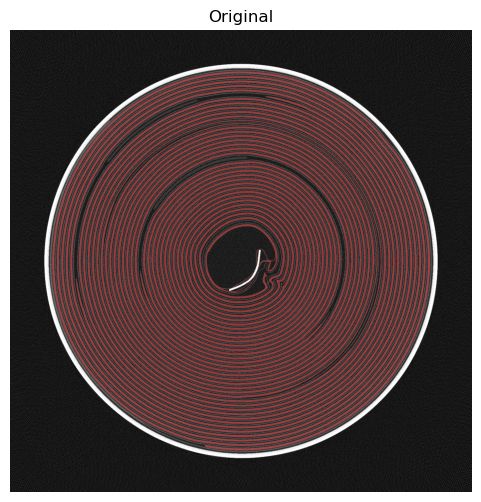

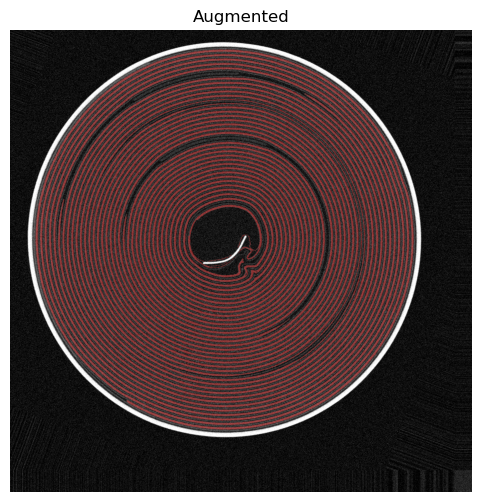

In [9]:
ct_aug, mask_aug = augment_pair(ct, mask, rng)

utils.plot_overlay(ct, mask, title="Original")
utils.plot_overlay(ct_aug, mask_aug, title="Augmented")

### 3.5 Visualise several augmented examples

The mask should remain spatially aligned with the CT image in every augmented example.

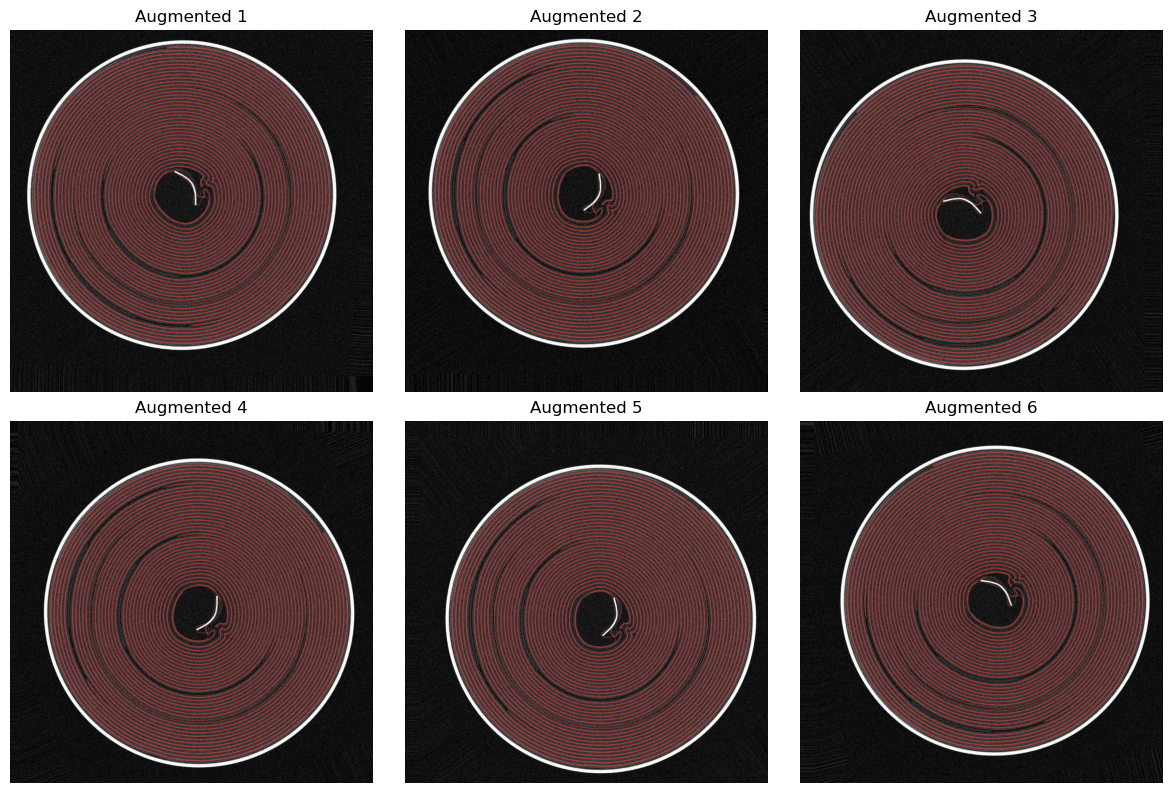

In [14]:
n_examples = 6

plt.figure(figsize=(12, 8))

for i in range(n_examples):
    ct_aug, mask_aug = augment_pair(ct, mask, rng)

    image_disp = utils.normalise_for_display(ct_aug)
    mask_binary = mask_aug > 0

    overlay = np.zeros((*mask_aug.shape, 4), dtype=np.float32)
    overlay[..., 0] = 1.0          # red
    overlay[..., 3] = mask_binary * 0.35  # alpha

    plt.subplot(2, 3, i + 1)
    plt.imshow(image_disp, cmap="gray")
    plt.imshow(overlay)
    plt.title(f"Augmented {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### 3.6 Save an augmented simulated dataset

We will now save augmented CT images and masks to a new folder.

The augmented dataset will be written to:

```text
data/afternoon/augmented_simulated_data/
├── CT_data/
└── Labels/
```
For each original image-mask pair, we will create a fixed number of augmented examples.

In [15]:
AUGMENTED_DATA_DIR = DATA_DIR / "augmented_simulated_data"
AUGMENTED_CT_DIR = AUGMENTED_DATA_DIR / "CT_data"
AUGMENTED_LABEL_DIR = AUGMENTED_DATA_DIR / "Labels"

AUGMENTED_CT_DIR.mkdir(parents=True, exist_ok=True)
AUGMENTED_LABEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Augmented CT output:     {AUGMENTED_CT_DIR}")
print(f"Augmented labels output: {AUGMENTED_LABEL_DIR}")

Augmented CT output:     /home/ucecmjo/Data/gVXR-training-dXCT2026/data/afternoon/augmented_simulated_data/CT_data
Augmented labels output: /home/ucecmjo/Data/gVXR-training-dXCT2026/data/afternoon/augmented_simulated_data/Labels


In [29]:
def save_augmented_dataset(
    pairs,
    output_ct_dir,
    output_label_dir,
    rng,
    n_augmented_per_image=2,
    max_images=None,
):
    """
    Save augmented CT image-mask pairs to disk.

    Set max_images to a small number while testing.
    Use max_images=None to process the full dataset.
    """
    if max_images is not None:
        pairs_to_process = pairs.head(max_images)
    else:
        pairs_to_process = pairs

    for _, row in tqdm(pairs_to_process.iterrows(), total=len(pairs_to_process)):
        image = imread(row["ct_path"])[507:-507,507:-507].astype(np.float32)
        mask = imread(row["label_path"])[507:-507,507:-507]
        mask = np.where(mask == 3, 1, 0).astype(np.uint8) # cathode phase is labelled 3

        for aug_idx in range(n_augmented_per_image):
            image_aug, mask_aug = augment_pair(image, mask, rng)

            key = row["key"]
            ct_out = output_ct_dir / f"CT-{key}_aug_{aug_idx:03d}.tiff"
            mask_out = output_label_dir / f"labels-{key}_aug_{aug_idx:03d}.tiff"

            imwrite(ct_out, image_aug.astype(np.float32))
            imwrite(mask_out, mask_aug.astype(mask.dtype))

    print("Finished saving augmented dataset.")

For testing, run it on a small number of images first:

In [30]:
#save_augmented_dataset(
#    pairs=pairs,
#    output_ct_dir=AUGMENTED_CT_DIR,
#    output_label_dir=AUGMENTED_LABEL_DIR,
#    rng=rng,
#    n_augmented_per_image=1,
#    max_images=5,
#)

100%|█████████████████████████████████████████████| 5/5 [00:00<00:00,  8.15it/s]

Finished saving augmented dataset.


Now save the whole dataset with augmentation applied

In [31]:
#save_augmented_dataset(
#    pairs=pairs,
#    output_ct_dir=AUGMENTED_CT_DIR,
#    output_label_dir=AUGMENTED_LABEL_DIR,
#    rng=rng,
#    n_augmented_per_image=1,
#    max_images=None,
#)

100%|███████████████████████████████████████| 3600/3600 [06:13<00:00,  9.64it/s]

Finished saving augmented dataset.


## 4. Prepare and augment the real data

We will now repeat a similar process for the real CT data.

The real dataset is split into training and test sets before augmentation. This is important because augmented versions of the same original image should not appear in both training and test sets.

For this workshop, we will use a 50/50 train/test split. This is not a typical split for a large dataset, but it is practical here because the real labelled dataset is small.

### 4.1 A note on test-set augmentation

In a strict model evaluation workflow, the final test set should usually be kept unmodified, apart from deterministic preprocessing. This gives the clearest estimate of how the model performs on genuinely held-out real data.

In this workshop, however, the real labelled dataset is very small. To make the test set large enough for demonstration purposes, we will also apply simple geometric augmentation to the test images. These augmented test examples should be interpreted as a workshop exercise and a basic robustness check, not as a fully independent estimate of model performance.

To avoid data leakage, the train/test split is performed before augmentation. This means augmented versions of a training image cannot appear in the test set, and augmented versions of a test image cannot appear in the training set.

### 4.2 Build real image-mask pairs

In [35]:
def key_from_real_recon_path(path):
    """
    Extract the slice number from a real CT filename.

    Example
    -------
    recon_slice1.tiff -> 1
    recon_slice12.tiff -> 6
    """
    name = path.name

    if not name.startswith("recon_slice"):
        raise ValueError(f"Unexpected real CT filename: {name}")

    key = name.removeprefix("recon_slice").removesuffix(".tif")
    return key

In [37]:
real_ct_paths = sorted(
    REAL_CT_DIR.glob("recon_slice*.tif"),
    key=lambda path: int(key_from_real_recon_path(path)),
)

rows = []

for ct_path in real_ct_paths:
    key = key_from_real_recon_path(ct_path)
    label_path = REAL_LABEL_DIR / f"seg{key}.tif"

    rows.append(
        {
            "key": key,
            "ct_path": ct_path,
            "label_path": label_path,
            "label_exists": label_path.exists(),
        }
    )

real_pairs = pd.DataFrame(rows)

print(f"Number of real CT images found: {len(real_pairs)}")
print(f"Number of missing labels:       {np.sum(~real_pairs['label_exists'])}")

real_pairs.head()

Number of real CT images found: 6
Number of missing labels:       0


,key,ct_path,label_path,label_exists
0,1,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,True
1,2,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,True
2,3,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,True
3,4,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,True
4,5,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,/home/ucecmjo/Data/gVXR-training-dXCT2026/data...,True


### 4.3 Split real data into training and test sets

In [38]:
from sklearn.model_selection import train_test_split

real_train_pairs, real_test_pairs = train_test_split(
    real_pairs,
    test_size=0.5,
    random_state=RANDOM_SEED,
    shuffle=True,
)

real_train_pairs = real_train_pairs.reset_index(drop=True)
real_test_pairs = real_test_pairs.reset_index(drop=True)

print(f"Real training pairs: {len(real_train_pairs)}")
print(f"Real test pairs:     {len(real_test_pairs)}")

Real training pairs: 3
Real test pairs:     3


### 4.4 Create output folders

In [39]:
AUGMENTED_REAL_DATA_DIR = DATA_DIR / "augmented_real_data"

REAL_TRAIN_CT_OUT = AUGMENTED_REAL_DATA_DIR / "train" / "CT_data"
REAL_TRAIN_LABEL_OUT = AUGMENTED_REAL_DATA_DIR / "train" / "Labels"

REAL_TEST_CT_OUT = AUGMENTED_REAL_DATA_DIR / "test" / "CT_data"
REAL_TEST_LABEL_OUT = AUGMENTED_REAL_DATA_DIR / "test" / "Labels"

for directory in [
    REAL_TRAIN_CT_OUT,
    REAL_TRAIN_LABEL_OUT,
    REAL_TEST_CT_OUT,
    REAL_TEST_LABEL_OUT,
]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Augmented real data output: {AUGMENTED_REAL_DATA_DIR}")

Augmented real data output: /home/ucecmjo/Data/gVXR-training-dXCT2026/data/afternoon/augmented_real_data


### 4.5 Define real-data augmentation functions

For the real training data, we will use the same augmentation strategy as before:

- random horizontal flips
- random vertical flips
- full-range rotations
- small translations
- mild Gaussian noise added to the CT image only

For the real test data, we will only use geometric augmentation:

- random horizontal flips
- random vertical flips
- full-range rotations

We avoid adding noise to the test data so that the test images remain closer to the real measured data.

In [40]:
def augment_pair_geometric_only(
    image,
    mask,
    rng,
    max_shift_pixels=0,
):
    """
    Apply geometric augmentation to a CT image and its mask.

    No noise is added.
    """
    image_aug = image.copy()
    mask_aug = mask.copy()

    if rng.random() < 0.5:
        image_aug = np.fliplr(image_aug)
        mask_aug = np.fliplr(mask_aug)

    if rng.random() < 0.5:
        image_aug = np.flipud(image_aug)
        mask_aug = np.flipud(mask_aug)

    angle = rng.uniform(0, 360)

    image_aug = ndi_rotate(
        image_aug,
        angle=angle,
        reshape=False,
        order=1,
        mode="nearest",
    )

    mask_aug = ndi_rotate(
        mask_aug,
        angle=angle,
        reshape=False,
        order=0,
        mode="constant",
        cval=0,
    )

    if max_shift_pixels > 0:
        shift_y = rng.uniform(-max_shift_pixels, max_shift_pixels)
        shift_x = rng.uniform(-max_shift_pixels, max_shift_pixels)

        image_aug = ndi_shift(
            image_aug,
            shift=(shift_y, shift_x),
            order=1,
            mode="nearest",
        )

        mask_aug = ndi_shift(
            mask_aug,
            shift=(shift_y, shift_x),
            order=0,
            mode="constant",
            cval=0,
        )

    return image_aug.astype(np.float32), mask_aug.astype(np.uint8)

### 4.6 Save augmented real training and test datasets

In [46]:
def save_augmented_real_dataset(
    pairs,
    output_ct_dir,
    output_label_dir,
    rng,
    n_augmented_per_image=2,
    split_name="train",
    use_noise=True,
    use_translation=True,
    max_images=None,
):
    """
    Save augmented real CT image-mask pairs to disk.

    The train set can use geometric augmentation plus noise.
    The test set can use geometric augmentation only.
    """
    if max_images is not None:
        pairs_to_process = pairs.head(max_images)
    else:
        pairs_to_process = pairs

    for _, row in tqdm(pairs_to_process.iterrows(), total=len(pairs_to_process)):
        image = imread(row["ct_path"]).astype(np.float32)
        image = cv2.resize(image, (1014, 1014), interpolation = cv2.INTER_AREA)

        mask = imread(row["label_path"])
        mask = cv2.resize(mask, (1014, 1014), interpolation = cv2.INTER_NEAREST)
        mask = np.where(mask == 3, 1, 0).astype(np.uint8)

        for aug_idx in range(n_augmented_per_image):
            if use_noise:
                image_aug, mask_aug = augment_pair(
                    image,
                    mask,
                    rng,
                    max_shift_pixels=20 if use_translation else 0,
                    noise_sigma=0.03,
                )
            else:
                image_aug, mask_aug = augment_pair_geometric_only(
                    image,
                    mask,
                    rng,
                    max_shift_pixels=20 if use_translation else 0,
                )

            key = row["key"]
            ct_out = output_ct_dir / f"CT-{key}_{split_name}_aug_{aug_idx:03d}.tiff"
            mask_out = output_label_dir / f"labels-{key}_{split_name}_aug_{aug_idx:03d}.tiff"

            imwrite(ct_out, image_aug.astype(np.float32))
            imwrite(mask_out, mask_aug.astype(np.uint8))

    print(f"Finished saving augmented {split_name} dataset.")

Run on a few images as a test

In [47]:
save_augmented_real_dataset(
    pairs=real_train_pairs,
    output_ct_dir=REAL_TRAIN_CT_OUT,
    output_label_dir=REAL_TRAIN_LABEL_OUT,
    rng=rng,
    n_augmented_per_image=2,
    split_name="train",
    use_noise=True,
    use_translation=True,
    max_images=3,
)

save_augmented_real_dataset(
    pairs=real_test_pairs,
    output_ct_dir=REAL_TEST_CT_OUT,
    output_label_dir=REAL_TEST_LABEL_OUT,
    rng=rng,
    n_augmented_per_image=2,
    split_name="test",
    use_noise=False,
    use_translation=False,
    max_images=3,
)

100%|█████████████████████████████████████████████| 3/3 [00:00<00:00,  4.33it/s]


Finished saving augmented train dataset.


100%|█████████████████████████████████████████████| 3/3 [00:00<00:00,  8.20it/s]

Finished saving augmented test dataset.


In [48]:
save_augmented_real_dataset(
    pairs=real_train_pairs,
    output_ct_dir=REAL_TRAIN_CT_OUT,
    output_label_dir=REAL_TRAIN_LABEL_OUT,
    rng=rng,
    n_augmented_per_image=120,
    split_name="train",
    use_noise=True,
    use_translation=True,
    max_images=None,
)

save_augmented_real_dataset(
    pairs=real_test_pairs,
    output_ct_dir=REAL_TEST_CT_OUT,
    output_label_dir=REAL_TEST_LABEL_OUT,
    rng=rng,
    n_augmented_per_image=33,
    split_name="test",
    use_noise=False,
    use_translation=False,
    max_images=None,
)

100%|█████████████████████████████████████████████| 3/3 [00:34<00:00, 11.66s/it]


Finished saving augmented train dataset.


100%|█████████████████████████████████████████████| 3/3 [00:05<00:00,  1.71s/it]

Finished saving augmented test dataset.


## Conclusion

In this notebook, we prepared the image-mask data needed for supervised CT segmentation.

We covered how to:

- organise simulated and real CT datasets;
- match CT images to their corresponding label masks;
- convert labels into a binary segmentation target;
- apply geometric augmentation safely to both images and masks;
- add noise to CT images only;
- split the real data into training and test sets before augmentation;
- save augmented datasets for later model training.

The main rule is that image-mask alignment must never be broken. Any geometric operation applied to a CT image must also be applied to its mask using nearest-neighbour interpolation for the mask.

The next notebook will use these prepared datasets to walk through the basic structure of a U-Net training workflow.